Google Colab code: plots for 
(1) SLM-only comparisons and
(2) Best-SLM vs LLM baselines (gap reduction)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [26]:
# Paths
METRICS_DIR = "/content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs"
FSD_CSV = os.path.join(METRICS_DIR, "fsd_metrics_all_models.csv")
FCS_CSV = os.path.join(METRICS_DIR, "fcs_metrics_all_models.csv")
DMA_CSV = os.path.join(METRICS_DIR, "dma_metrics_all_models.csv")

# Save figures back to Drive (recommended)
OUT_DIR = os.path.join(METRICS_DIR, "figs")
os.makedirs(OUT_DIR, exist_ok=True)

/tmp/ipython-input-2955622388.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")


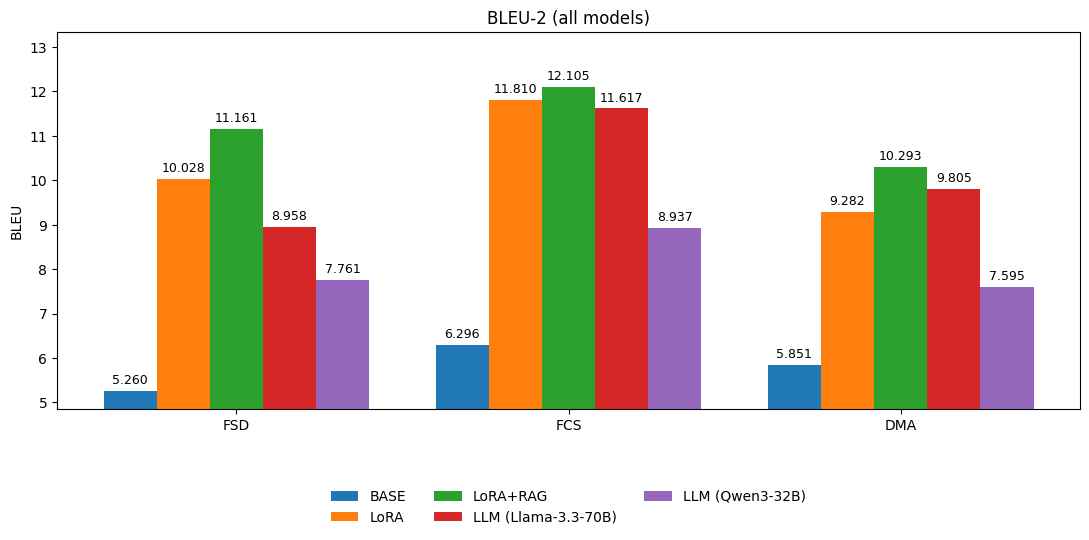

Saved: /content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs/figs/all_bleu.png


/tmp/ipython-input-2955622388.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")


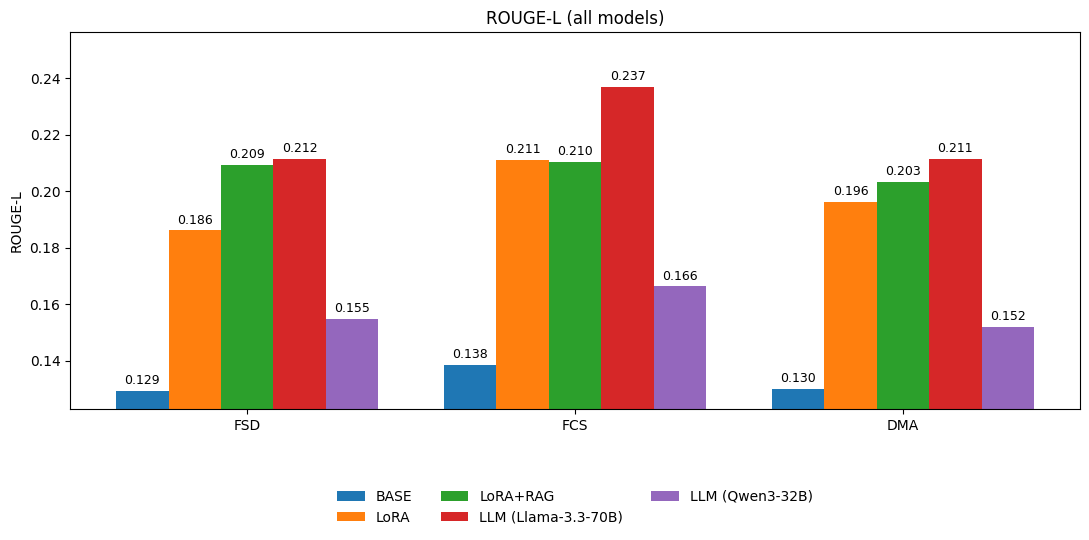

Saved: /content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs/figs/all_rougeL.png


/tmp/ipython-input-2955622388.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")


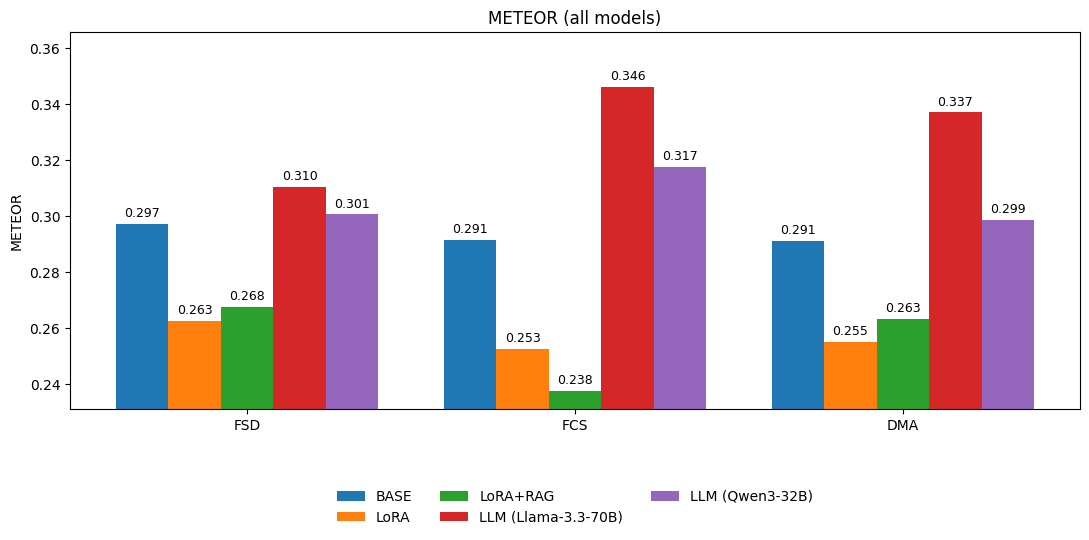

Saved: /content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs/figs/all_meteor.png


/tmp/ipython-input-2955622388.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")


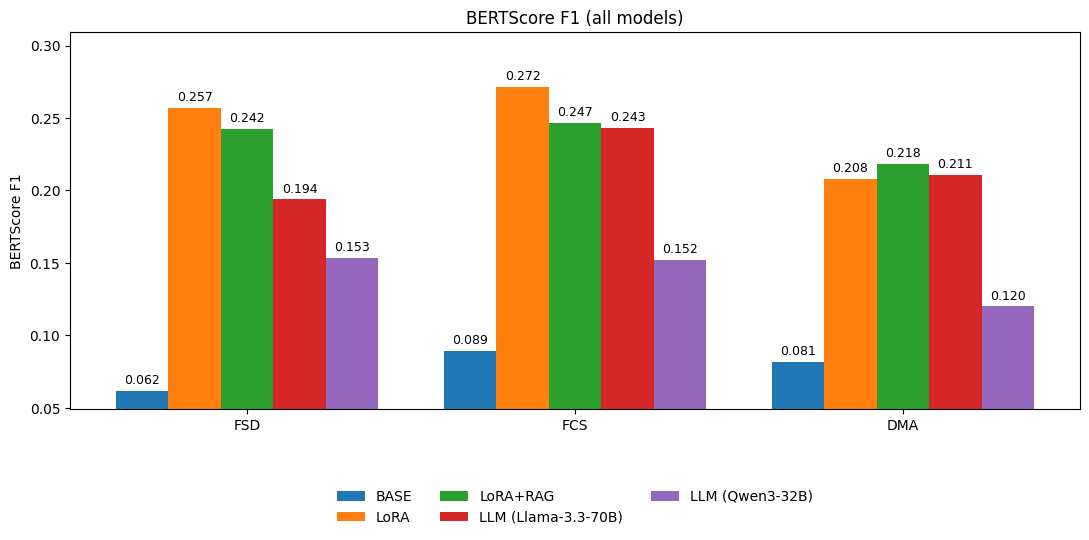

Saved: /content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs/figs/all_bertscore.png


/tmp/ipython-input-2955622388.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")


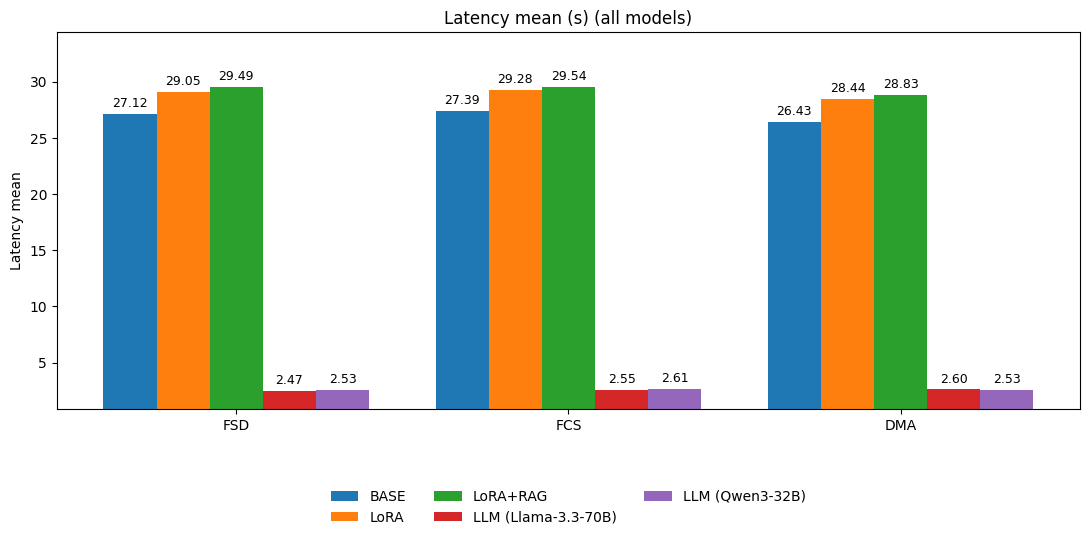

Saved: /content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs/figs/all_latency_mean.png


/tmp/ipython-input-2955622388.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")


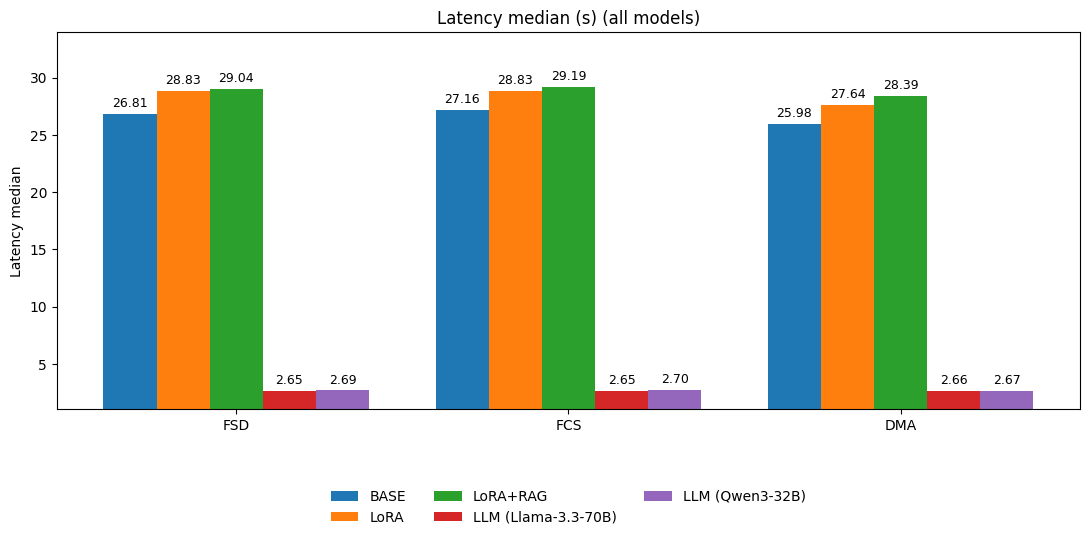

Saved: /content/drive/MyDrive/Colab Notebooks/agentic-ai-tutor/metrics_outputs/figs/all_latency_median.png


In [27]:


ALL_MODELS_ORDER = [
    "BASE",
    "LoRA",
    "LoRA+RAG",
    "LLM (Llama-3.3-70B)",
    "LLM (Qwen3-32B)",
]

def plot_all_models(all_df: pd.DataFrame, metric: str, title: str, filename: str, fmt="%.3f"):
    subjects = ["FSD", "FCS", "DMA"]
    models = ALL_MODELS_ORDER

    df = all_df[all_df["Model"].isin(models)].copy()
    df["Model"] = pd.Categorical(df["Model"], categories=models, ordered=True)

    pivot = (
        df.pivot_table(index="subject", columns="Model", values=metric, aggfunc="mean")
          .reindex(subjects)
          .reindex(columns=models)
    )

    x = np.arange(len(subjects))
    width = 0.16
    offsets = np.linspace(-2, 2, len(models)) * width

    fig, ax = plt.subplots(figsize=(11, 5.6))

    bars = []
    for i, m in enumerate(models):
        b = ax.bar(x + offsets[i], pivot[m].values, width=width, label=m)
        bars.append(b)

    ax.set_xticks(x)
    ax.set_xticklabels(subjects)
    ax.set_ylabel(metric)
    ax.set_title(title)

    for b in bars:
        ax.bar_label(b, fmt=fmt, padding=3, fontsize=9)

    vals = pivot.values.flatten()
    vals = vals[~np.isnan(vals)]
    if len(vals) > 0:
        vmin, vmax = float(np.min(vals)), float(np.max(vals))
        if vmax == vmin:
            ax.set_ylim(vmin - 1, vmax + 1)
        else:
            top_pad = 0.18
            bottom_pad = 0.06
            y0 = vmin - abs(vmax - vmin) * bottom_pad
            y1 = vmax + abs(vmax - vmin) * top_pad
            ax.set_ylim(y0, y1)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)

    fig.tight_layout()
    out_path = os.path.join(OUT_DIR, filename)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

# ==========
# Calls
# ==========
plot_all_models(all_df, "BLEU",         "BLEU-2 (all models)",              "all_bleu.png", fmt="%.3f")
plot_all_models(all_df, "ROUGE-L",      "ROUGE-L (all models)",             "all_rougeL.png", fmt="%.3f")
plot_all_models(all_df, "METEOR",       "METEOR (all models)",              "all_meteor.png", fmt="%.3f")
plot_all_models(all_df, "BERTScore F1", "BERTScore F1 (all models)",        "all_bertscore.png", fmt="%.3f")
plot_all_models(all_df, "Latency mean", "Latency mean (s) (all models)",    "all_latency_mean.png", fmt="%.2f")
plot_all_models(all_df, "Latency median","Latency median (s) (all models)", "all_latency_median.png", fmt="%.2f")